# Lecture 31: Ant Colony Optimization - Algorithm

---

```{note}
Lecture 30 developed Ant Colony Optimization's construction rule and pheromone update for a graph, and previewed **ACOR** — the archive-based adaptation needed for a continuous problem, since a continuous function has no edges for pheromone to live on. This lecture implements ACOR and applies it to the same Ackley function Lectures 25 and 28 used, completing this module's pattern of a first hands-on encounter on a controlled benchmark. ACOR's job ends here — Lecture 32 moves to real routing benchmarks, where ACO's *native* graph-based form applies directly and needs no bridge at all.
```

**Learning Objectives**

By the end of this notebook, you will be able to:
1. Implement ACOR's archive-based construction for continuous problems.
2. Run ACOR on a continuous test function and interpret its convergence.
3. Explain how ACOR's archive plays the same role for continuous problems that a pheromone matrix plays for a graph.

**Prerequisites**: Ant Colony Optimization - Motivation & Pseudocode (Lecture 30); Genetic Algorithm - Algorithm (Lecture 28).

**Estimated time**: 50 minutes

---

## From Archive to Python

Lecture 30 previewed the idea: instead of a pheromone matrix on a graph, ACOR keeps an **archive** of the $k$ best real-valued solutions found so far, ranked by quality. A new candidate is built one dimension at a time: pick an archive member (better-ranked members more likely), then sample a new value from a Gaussian centred on that member's value, with a spread based on how far apart the archive's members already are there. New candidates are merged into the archive, which is trimmed back to its best $k$.

```{note}
This lecture uses a **simplified rank weighting** — weight $\propto 1/\text{rank}$ — rather than the Gaussian-of-ranks formula in Socha and Dorigo's original paper, the same kind of simplification Lecture 28 made to the Genetic Algorithm's textbook crossover formula to keep the mechanism clear within a 50-minute lecture.
```

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def acor(X_o, f, k, xi, m, n=200, t=1e-9):
    """ACOR: archive-based continuous ant colony optimization.

    Parameters
    ----------
    X_o : initial candidate solutions (list of arrays), len(X_o) >= k
    f   : objective (minimized)
    k   : archive size
    xi  : deviation-scaling parameter
    m   : number of new candidates constructed per iteration
    """
    dim = len(X_o[0])
    archive = sorted([np.array(x, dtype=float) for x in X_o], key=f)[:k]
    weights = np.array([1.0 / (i + 1) for i in range(k)])     # simplified rank weighting
    weights /= weights.sum()

    s_b = archive[0]
    f_b = f(s_b)
    F_b = [f_b]
    it, imp, converged = 0, float("inf"), False
    while not converged:
        new_solutions = []
        for _ in range(m):
            x_new = np.zeros(dim)
            for j in range(dim):
                l = np.random.choice(k, p=weights)                  # pick an archive member
                mu = archive[l][j]
                sigma = xi * sum(abs(archive[l][j] - archive[o][j]) for o in range(k)) / (k - 1)
                x_new[j] = np.random.normal(mu, sigma if sigma > 1e-12 else 1e-6)
            new_solutions.append(x_new)
        archive = sorted(archive + new_solutions, key=f)[:k]        # keep the k best
        if f(archive[0]) < f_b:
            imp = f_b - f(archive[0])
            f_b = f(archive[0])
            s_b = archive[0]
        F_b.append(f_b)
        it += 1
        if it >= n or imp <= t:
            converged = True
    return s_b, F_b

def ackley(s):
    x, y = s
    return (-20 * np.exp(-0.2 * np.sqrt((x ** 2 + y ** 2) / 2))
            - np.exp((np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)) / 2)
            + 20 + np.e)

print("acor() and ackley() defined.")

acor() and ackley() defined.


## Applying ACOR

In [2]:
random.seed(42)
np.random.seed(42)
X_o = [np.random.uniform(-5, 5, 2) for _ in range(30)]
print("Initial archive pool size:", len(X_o))
print("Best in initial pool:", round(min(ackley(x) for x in X_o), 5))

random.seed(42)
np.random.seed(42)
s_b, F_b = acor(X_o, ackley, k=10, xi=1.0, m=10, n=200, t=1e-12)
print("\nBest point found:", tuple(round(v, 6) for v in s_b))
print("Best f found:", f"{ackley(s_b):.2e}", " (global optimum: f(0,0) = 0)")

Initial archive pool size: 30
Best in initial pool: 5.72963

Best point found: (np.float64(0.0), np.float64(-0.0))
Best f found: 4.01e-12  (global optimum: f(0,0) = 0)


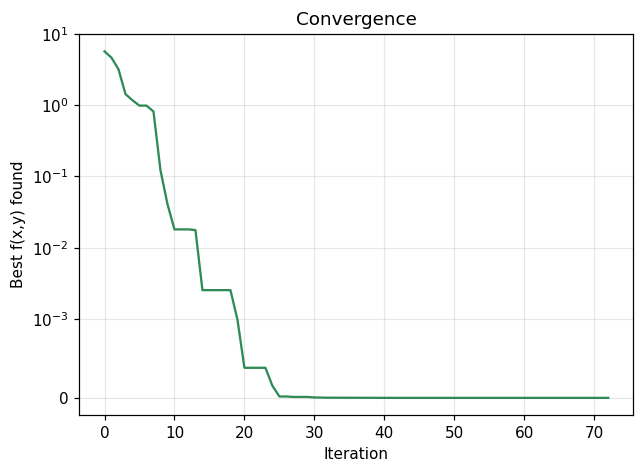

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(F_b, color="seagreen", linewidth=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Best f(x,y) found")
ax.set_title("Convergence")
ax.set_yscale("symlog", linthresh=1e-3)
ax.grid(alpha=0.3)
plt.show()

```{note}
ACOR reaches essentially the exact optimum here, and quickly — the archive concentrates around the best region within the first few dozen iterations, then keeps refining. Compare this to Lectures 25 and 28's convergence plots: all three algorithms eventually flatten out near their best value, but each gets there through a different mechanism — SA by cooling a single solution's willingness to wander, GA by a population's crossover and selection, ACOR by an archive's members clustering tighter around the best-found region as worse candidates keep failing to make the cut.
```

---

## In-Class Exercise

### Exercise 1 — Does the Archive Size Matter?

Repeat the run above with a much smaller archive, keeping everything else identical.

In [4]:
random.seed(42)
np.random.seed(42)
X_o_small = [np.random.uniform(-5, 5, 2) for _ in range(30)]
random.seed(42)
np.random.seed(42)
s_b_small, F_b_small = acor(X_o_small, ackley, k=5, xi=1.0, m=10, n=200, t=1e-12)

print("k=10 (main demo) best f:", f"{ackley(s_b):.2e}")
print("k=5  (this exercise) best f:", f"{ackley(s_b_small):.2e}")

k=10 (main demo) best f: 4.01e-12
k=5  (this exercise) best f: 1.57e-04


**Interpretation.** Both archive sizes land close to zero given this generous 200-iteration budget, but not equally close: $k=10$ reaches $4\times10^{-12}$, while $k=5$ only reaches $1.6\times10^{-4}$ — visually both look like "the optimum" on a linear scale, but they differ by eight orders of magnitude. A smaller archive has fewer reference points to sample around, and can settle into a tight cluster slightly off-centre with less to pull it the rest of the way. This is worth remembering as a general lesson: even a generous budget doesn't make a parameter's effect disappear — it can just make the effect harder to *see* at a casual glance, exactly the kind of gap Lecture 32 makes visible for native ACO's own parameters by tightening the budget, the same practice Lectures 26 and 29 already used for Simulated Annealing's cooling rate and the Genetic Algorithm's population size.

---

## Take-Away Exercises

### Exercise 1 — A Different Starting Pool

Re-run this lecture's main demo with three different random seeds. Does ACOR reach a similarly good result every time?

### Exercise 2 — Tracking the Archive

Modify `acor()` to record the *entire* archive (not just its best member) after every iteration, and plot how the spread of $f$ values across the archive narrows over time. Does the archive's diversity collapse gradually or suddenly?

---

## Circling Back

- **Lecture 30 (Ant Colony Optimization: Motivation & Pseudocode)**: `acor()` above is a direct implementation of that lecture's preview — the archive replacing the pheromone matrix, Gaussian sampling replacing graph-edge construction.
- **Lecture 25 (Simulated Annealing: Algorithm)** and **Lecture 28 (Genetic Algorithm: Algorithm)**: all three algorithms have now been applied to the identical Ackley function, from the same random seed, via three structurally different mechanisms.

## Moving Forward

- **Lecture 32 (Ant Colony Optimization: Benchmarking)**: moves to real TSPLIB routing benchmarks, where ACO's *native* graph-based form (Lecture 30's original pseudocode) applies directly with no archive, no Gaussian sampling, and no bridge of any kind — calibrated there the same way Lectures 26 and 29 calibrated Simulated Annealing and the Genetic Algorithm.

---

## Further Reading

- Socha, K. and Dorigo, M. (2008). "Ant Colony Optimization for Continuous Domains." *European Journal of Operational Research*, 185(3), 1155-1173 — the original ACOR formulation.
- Liao, T., Socha, K., Montes de Oca, M.A., Stützle, T., and Dorigo, M. (2014). "Ant Colony Optimization for Mixed-Variable Optimization Problems." *IEEE Transactions on Evolutionary Computation*, 18(4), 503-518.